# Module 2: Epidemic Modeling

## Team Members: Will Marschall and Reagan Oswald

## Project Title: Mystery Virus Outbreak Modeling

## Project Goal: This project seeks to use sequential outbreak data releases to estimate how quickly a mystery virus spreads, fit an SEIR epidemic model to observed infection data, evaluate how well that model predicts future outbreak behavior, and recommend interventions for reducing spread in a new university population.

## 1. Data and disease background
### 1a. Mystery Virus
We used the fitted SEIR parameters from our later model analysis, together with literature research, to identify the mystery virus. Our early Day 1 exponential-growth estimate gave a provisional $R_0 \approx 2.937$, but our main mechanistic estimate from the fitted SEIR model in Data Release #2 was $R_0 = \frac{\beta}{\gamma} \approx \frac{0.586}{0.107} \approx 5.467.$

We used the early $R_0$ only as an initial screening estimate. For our final virus identification, we relied more heavily on the later SEIR-based estimate, the respiratory symptom pattern, and the timing clues provided in class.

Based on the combination of transmissibility, respiratory spread, symptom pattern, and timing, the virus that best matches our project data is **respiratory syncytial virus (RSV)**, which belongs to the **Pneumoviridae** family [1]–[4]. RSV is a respiratory virus that commonly causes cough, congestion, sneezing, fever, wheezing, and runny nose, which is consistent with the type of outbreak behavior and symptom profile discussed in lecture [1], [2].

Using `viruses.html` only as a rough comparison, RSV is also one of the closest diseases to our fitted $R_0$ because the chart places RSV near $R_0 = 6$, which is close to our main fitted value of $5.467$. However, we did not rely on the chart alone because $R_0$ by itself is not enough to identify a virus.

The timing evidence also supports RSV better than many of the other rough chart matches. CDC reports that RSV symptoms usually appear **4–6 days** after infection, and infected people are usually contagious for **3–8 days**, with contagiousness beginning **a day or two before symptoms appear** [1], [2]. Those values are not identical to our fitted latent period of about **8.8 days** and infectious period of about **9.3 days**, but they are still more consistent with the mystery-virus clues than alternatives such as norovirus. Norovirus usually has an incubation period of only **12–48 hours** and causes acute gastrointestinal illness, which does not match a respiratory-style outbreak [5].

Therefore, our final interpretation is that the mystery virus is **most consistent with RSV or an RSV-like respiratory virus in the Pneumoviridae family**, while also acknowledging that our fitted SEIR parameters are population-level approximations rather than exact one-to-one biological measurements for a specific pathogen.




### 1b. Disease Background

#### 1) Prevalence at UVA  

   The maximum observed prevalence in the UVA outbreak dataset was **3294** active cases, and the observed prevalence at the end of the 120 days was **613** active cases. These values came directly from the full Data Release #3 active-case dataset.

#### 2) Incidence at UVA  

   We approximated incidence in the model as the number of new exposures per day, $\beta \frac{SI}{N}.$
   Using our fitted model output, the maximum modeled incidence was approximately **394** new cases per day, and the modeled incidence by day 120 was close to **0.39** new cases per day. This supports the idea that transmission had slowed substantially by the end of the observed outbreak.

#### 3) Economic burden  

   If the mystery virus is RSV-like, the economic burden would include both direct and indirect costs. Direct costs can include clinic visits, diagnostic testing, emergency care, hospitalization, oxygen support, and treatment of complications such as bronchiolitis or pneumonia in more severe cases [3], [4]. Indirect costs can include missed class time, missed work, caregiving burden, and disruption to campus activities during a large respiratory outbreak.

#### 4) Symptoms  

   RSV usually causes respiratory symptoms such as **runny nose, congestion, cough, sneezing, fever, wheezing, and decreased appetite** [1], [2]. These symptoms are consistent with an upper or lower respiratory viral infection and fit better with our outbreak interpretation than gastrointestinal viruses such as norovirus.

#### 5) Biological mechanisms  

   RSV is an enveloped, negative-sense single-stranded RNA virus in the Pneumoviridae family [3]. Like other respiratory viruses, it cannot reproduce on its own and must enter host airway cells and use host-cell machinery to make new viral particles.

   - **Attachment:** RSV attaches to host respiratory epithelial cells using viral surface proteins that allow the virus to bind and enter susceptible cells [3].

   - **Penetration:** After attachment, the virus enters host cells and releases its RNA genome into the cell, where replication can begin [3].

   - **Genome replication:** RSV uses the host cell environment to transcribe and replicate its RNA genome and produce viral proteins needed for assembly of new virions [3].

   - **Assembly and spread:** Newly assembled viral particles are released and can infect neighboring cells in the respiratory tract, increasing viral load and contributing to symptoms and contagious spread [3].

## 2. Data Analysis

### 2a. Methods

#### Data Release 1 (Initial Estimates and Approximations)

We loaded the Data Release #1 CSV containing day number and active reported daily cases, and plotted **day vs. active infections**.

To estimate early spread speed, we used the Day 2 approach that early epidemic growth can be approximated as continuous exponential growth, $(I(t) = I_0 e^{rt})$, where $(r)$ is estimated by fitting an exponential curve to early infection data.

This early exponential approximation is most appropriate at the beginning of the outbreak, when the susceptible population is still large and depletion/recovery effects are not yet dominating the curve.

We then estimated $(R_0)$ using the Day 2 approximation $R_0 \approx e^{rD}$, where $(D)$ is the infectious period. For $(D)$, we used the “New information about our mystery virus” statement that the symptomatic period is 5–9 days and individuals are infectious for 2 days before symptoms appear, giving $(D \approx [7, 11])$ days.

Finally, we used the provided `viruses.html` visualization to identify diseases with similar $R_0$ and compare approximate transmissibility and case fatality rate (CFR). We treated this comparison only as a rough first-pass screening step. Our final virus identification was based more heavily on the later SEIR-based $R_0$, the timing clues from lecture, respiratory symptom patterns, and literature comparison.

At this stage, only the early outbreak growth rate was reasonably knowable, not the full epidemic peak or the later compartment dynamics. Because the first release contains only early data, our $R_0$ estimate should be interpreted as temporary and sensitive to assumptions such as the chosen fitting window and the infectious-period range $D$. In addition, this early estimate may be biased because reported active cases can lag true infections, not every infection is necessarily observed, and the fitted growth rate depends on which early time window is chosen for the exponential fit. With later releases, we expect confidence to improve because more of the outbreak trajectory become observable.

#### Data Release 2 (SEIR modeling + parameter fitting)

For Data Release #2, we modeled the outbreak using an **SEIR compartment model** and solved the system numerically with **Euler’s method**. Euler’s method uses the update rule $y_{i+1}=y_i+f(t_i,y_i)h$. We used the SEIR differential equations shown in class:
$\frac{dS}{dt}=-\beta \frac{SI}{N}$,
$\frac{dE}{dt}=\beta \frac{SI}{N}-\sigma E$,
$\frac{dI}{dt}=\sigma E-\gamma I$,
$\frac{dR}{dt}=\gamma I$

We then fit parameters $\beta$ (transmission), $\sigma$ (incubation/latency rate), and $\gamma$ (recovery rate) by performing a 3-parameter grid search that minimizes the objective function
$\mathrm{SSE}=\sum (I_{\mathrm{obs}}-I_{\mathrm{model}})^2$

We used the parameter ranges and resolution specified in `seir_grid_search.html`: $\beta \in [0.3,0.7]$, $\sigma \in [0.1,0.3]$, $\gamma \in [0.05,0.25]$ with 15 points per parameter. After this initial coarse search, we performed a narrower second-pass grid search around the first best-fit parameter set to improve parameter resolution while keeping the overall fitting methodology the same.

Finally, we computed an implied basic reproduction number using the relationship $R_0=\beta/\gamma$ and predicted the peak by running the best-fit model forward in time and finding the maximum of $I(t)$.

Data Release #2 made it possible to estimate mechanistic SEIR parameters and generate a forward peak prediction, but uncertainty still remained because the model had not yet been tested against future observations. Data Release #3 therefore will have value as a validation dataset: it will allow us to evaluate whether the Release #2 fit actually generalized beyond the calibration window.

**Modeling assumption:** We set $N=10{,}000$ to match the example population size used in class. If a different population size is wanted for the mystery outbreak, we can update $N$ accordingly.

#### Data Release 3 (model validation + intervention analysis)
For our Data Release #3, we used the best-fit SEIR parameters from the Data Release #2 and compared that model to the full 120-day outbreak dataset. We again solved the SEIR system with Euler's method using the update rule $y_{i+1}=y_i+f(t_i,y_i)h$ and plotted model-predicted active infections $I(t)$ against the observed active infection counts from Release #3.

To evaluate prediction accuracy, we compared the model prediction to the full Data Release #3 infection counts and evaluated using the definitions of true error $E_t ​= true value − approximation$ and true percent relative error $ \%e_t ​= (true value−approximation) / true value ​× 100\% $.

Second, we used the same fitted SEIR parameters to model intervention strategies for a new outbreak at Virginia Tech (VT), following the setup explained during class. We used VT's student population as the susceptible pool, with initial conditions: $ S_0 = N - E_0 - I_0 - R_0 $, where $ N = 38,294$, $I_0 = 1$, $R_0 = 0$, and $E_0(VT) = E_0(UVA)$. We simulated a baseline no-intervention scenario through day 120, then applied four intervention scenarios beginning at day 70: a masking mandate that reduced transmission by 40%, a single vaccine campaign moving $2000 * 0.9$ individuals from $S$ to $R$ at day 70, a vaccine rollout moving $1000 * 0.9$ individuals from $S$ to $R$ at days 70, 80, and 90, and an additional combined intervention that applied both masking and the staged vaccine rollout together. We compared interventions to baseline using both peak infections and the summed active infections over days 70–120 as a simple burden metric.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)

### **Day 1 - Part 2B**

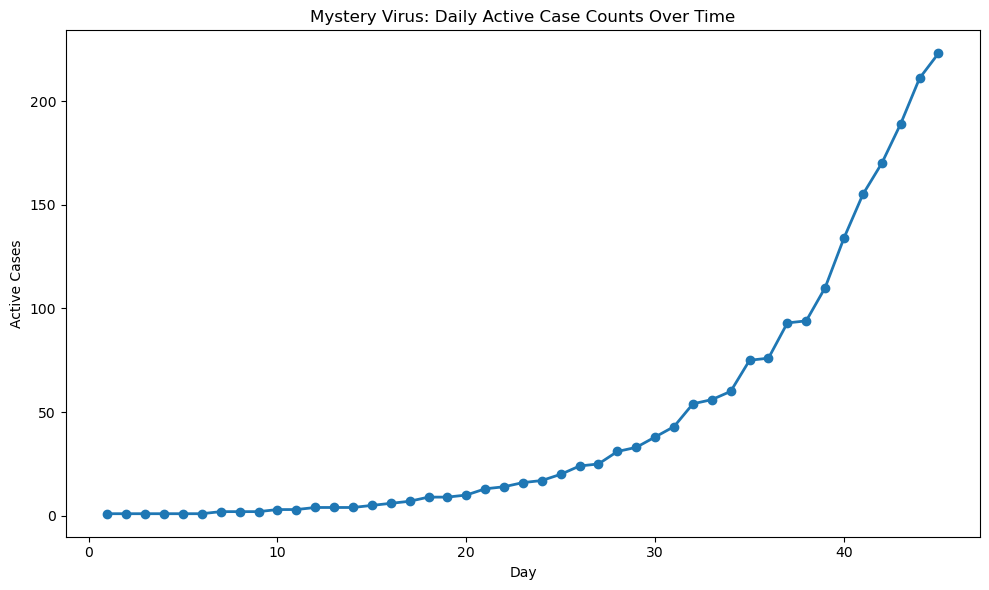

In [1]:
# This allows us to view the plots/outputs inline instead of having pages and pages of code
# If you would like to see the full code/comments, go under the 'Code' folder and open the .py files, making sure to change the file paths
from IPython.display import display, Markdown

def step(title: str):
    display(Markdown(f"### **{title}**"))

step("Day 1 - Part 2B")
import main
main.exploratory_analysis_day1_2b()

**What do you notice about the initial infections?**

Initially, in the early days, the infection had spread to only a few people. But the number of active cases increases exponentially because when more people are infected, they can spread the infection much more quickly.

**How could we measure how quickly its spreading?**

By finding the rate of change of the graph we can measure how quickly the infection spreads as a rate across days. 

**What information about the virus would be helpful in determining the shape of the outbreak curve?**

It would be helpful to know how the virus spreads. Viruses that spread more easily will likely have a greater rate of  infection and result in a greater outbreak curve. For example, an airborne virus may infect a population faster than one that spreads fluids

### **Day 2 - Part 2B**

Fit window: day >= 10
Estimated exponential growth rate r: 0.1197 per day
Estimated R0 range using D in [7.0, 11.0] days:
  R0_min (D=7.0) = 2.312
  R0_mid (D=9.0) = 2.937
  R0_max (D=11.0) = 3.732


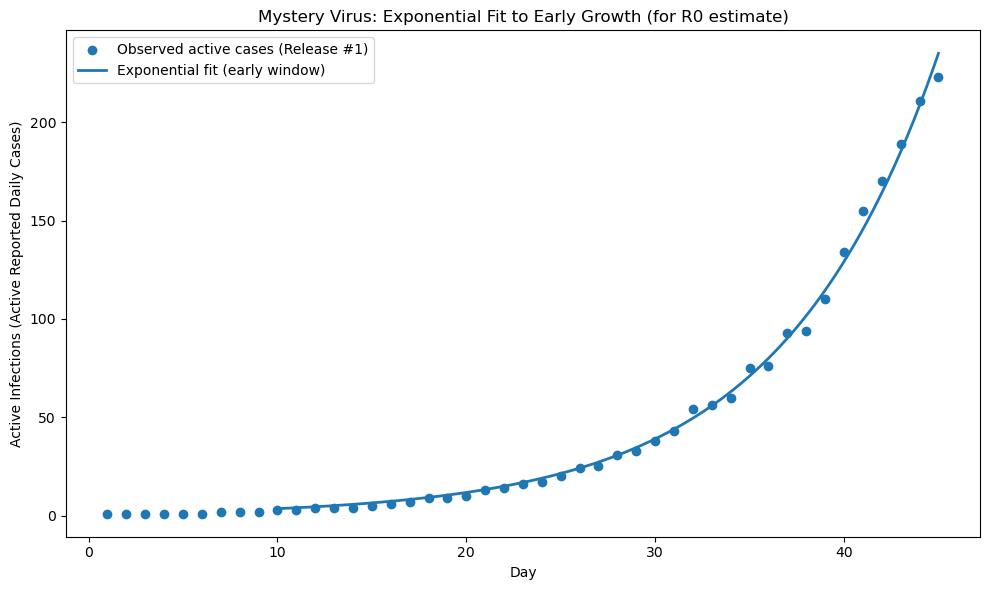

In [2]:
step("Day 2 - Part 2B")
main.exploratory_analysis_day2_2b()

**What viruses have a similar R0? Use the viruses.html file to find a virus or 2 with a similar R0 and give a 1-2 sentence background of the diseases.**

COVID-19 (Original) was found to be near my $R_0$ (2.937). It reported to have a $R_0$ of 3 and $CFR = 1%$, and it is marked under the "Vaccine Available" category. COVID-19 has an ~5-day incubation period and it can be infectious ~2 days before symptoms. 

Zika was found to be near my $R_0$ (2.937). It reported to have a $R_0$ of 3 and $CFR = 0.02%$, and it is marked under the "No Vaccine" category. Zika virus is a mosquito-borne pathogen that gained global attention during a 2015 outbreak.

We use these only as rough early comparisons because this estimate came from limited early-growth data and is not our final identification.

**How accurate do you think your R0 estimate is?**

My $R_0$ is reasonable but approximate, because we explicitly treat this as an early-epidemic approximation based on fitting exponential growth and then converting. The biggest uncertainty is $D$ (infectious period) as we only have limited timing information (symptomatic period 5-9 days). Also the fitted growth rate $r$ can change depending on which days we treat as the "early exponential window" (we chose day >= 10, and viruses.html notes that $R_0$ estimates vary with behavior and population density).


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.

### **Day 3 - Part 2C**

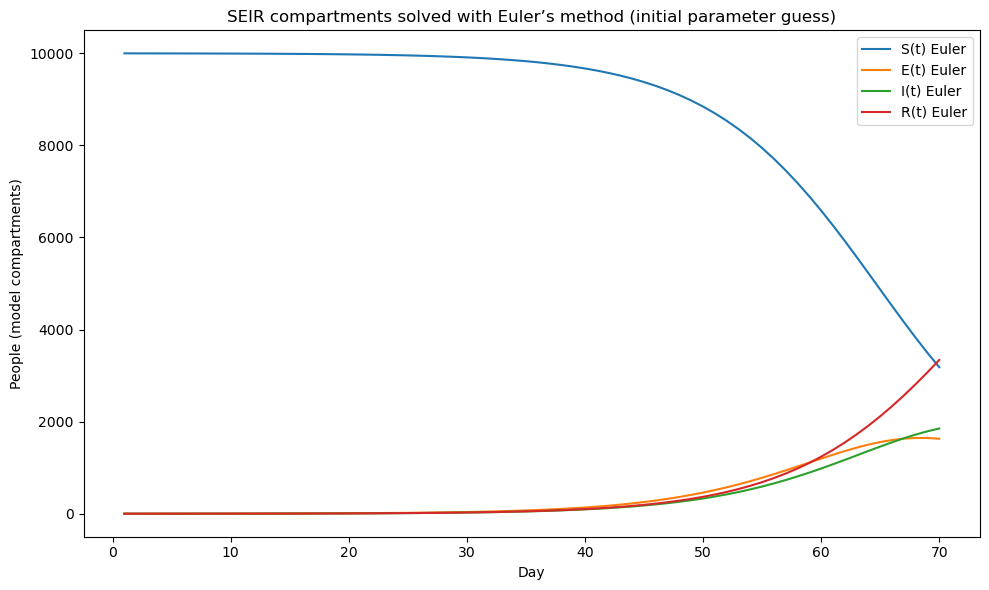

In [3]:
step("Day 3 - Part 2C")
main.exploratory_analysis_day3_2c()

We solved the SEIR system using Euler’s method, applying the update rule $y_{i+1}=y_i+f(t_i,y_i)h$.

Using an initial parameter guess within the grid-search ranges $\beta=0.5,\sigma=0.2,\gamma=0.15$; chosen as mid-range values from `seir_grid_search.html`, the Euler solution produced the expected qualitative compartment behavior: $S(t)$ decreases while $E(t),I(t),R(t)$ increase over the observed 70 days. This confirmed to us that our Euler implementation is correctly propagating the SEIR dynamics described in the equations we talked about in class.

### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.

In [10]:
step("Day 3 - Part 2D")
main.exploratory_analysis_day3_2d()

### **Day 3 - Part 2D**

Best-fit parameters from 3-parameter grid search (min SSE):
  beta  = 0.586
  sigma = 0.114
  gamma = 0.107
  SSE   = 98824.33
  Implied R0 (R0 = beta/gamma) = 5.467


We first fitted $\beta,\sigma,\gamma$ using a 3-parameter grid search that minimizes
$\mathrm{SSE}=\sum (I_{\mathrm{obs}}-I_{\mathrm{model}})^2$. We used the ranges/resolution from `seir_grid_search.html`:
$\beta \in [0.3,0.7]$, $\sigma \in [0.1,0.3]$, $\gamma \in [0.05,0.25]$ with 15 points per parameter. We used those bounds because they were the provided plausible search region for this outbreak, allowing us to explore a broad but still biologically reasonable parameter space without making the grid search unnecessarily large or computationally wasteful.

Best-fit results (minimum SSE):

- $\beta = 0.586$

- $\sigma = 0.114$

- $\gamma = 0.107$

- $\mathrm{SSE} = 98{,}824.33$

Using the relationship $R_0=\beta/\gamma$, the implied
$R_0 \approx 0.586/0.107 \approx 5.467$.

Interpreting $\sigma$ and $\gamma$ using definitions ($\sigma=1/\text{latent period}$, $\gamma=1/\text{infectious period}$):

- Latent period $\approx 1/\sigma \approx 1/0.114 \approx 8.8$ days

- Infectious period $\approx 1/\gamma \approx 1/0.107 \approx 9.3$ days

### 2e. Plot the model-predicted infections over time compared to the data.

### **Day 3 - Part 2E**

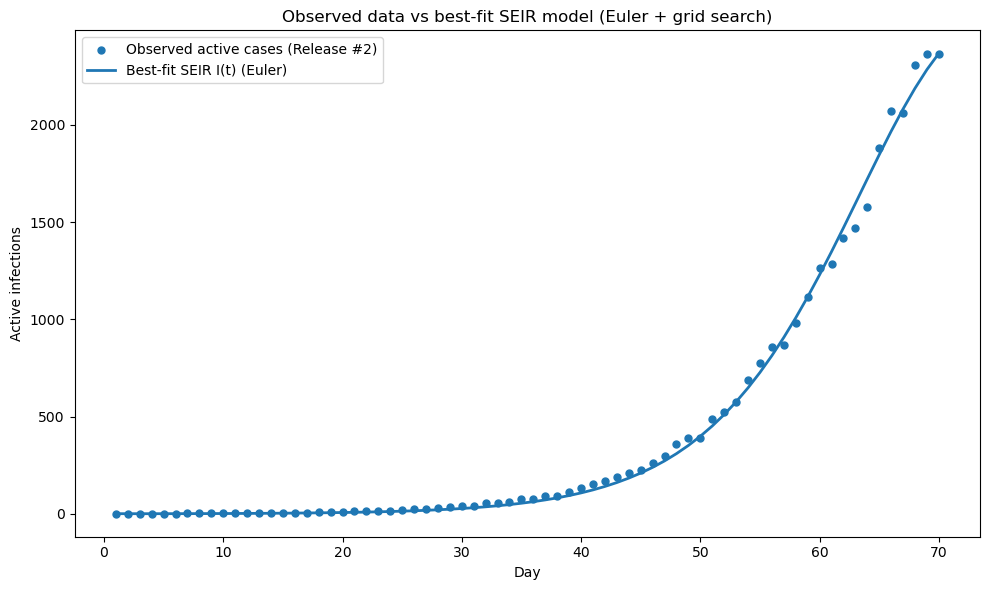

In [5]:
step("Day 3 - Part 2E")
main.exploratory_analysis_day3_2e()

Using the best-fit parameters from 2d, we solved the SEIR model again with Euler’s method and plotted the model-predicted $I(t)$ against the observed active infection counts from Data Release #2.

In a visual sense, the best-fit SEIR curve closely tracks the observed data through the rapid growth phase and remains near the final observed values (e.g., the dataset reaches 2,363 active cases at day 70). This indicates the chosen $\beta,\sigma,\gamma$ minimize SSE over the full 70-day dataset under the grid-search procedure.

### 2f. Predict the day and amount of active cases at the peak of the epidemic spread.

### **Day 3 - Part 2F**


Peak prediction from best-fit model (running forward):
  Peak day (model)        = 75
  Peak active infections  = 2556.4


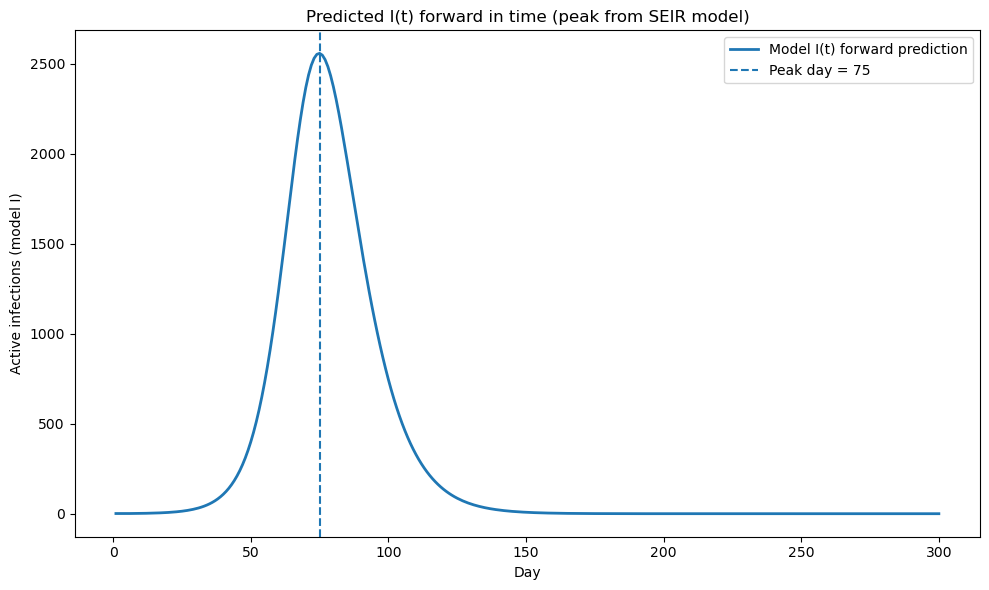

In [6]:
step("Day 3 - Part 2F")
main.exploratory_analysis_day3_2f()

We saw how lecture 3 describes predicting the peak by running the best-fit model forward in time and finding when $I(t)$ reaches its maximum. Using our best-fit $\beta,\sigma,\gamma$, we ran the Euler SEIR simulation forward to day 300 and located the maximum of $I(t)$.

Peak prediction (model):

- Predicted peak day = 75

- Predicted peak active infections = 2,556.4

Because the observed dataset ends at day 70 with 2,363 active infections, the model predicts the peak occurs about 5 days after the last observation and rises by about 193.4 active cases beyond the day-70 observed value.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2g. Plot the full dataset (Data Release #3) against your model.


### **Day 4 - Part 2g**


Release #3 vs model fit from Release #2
Best-fit beta  = 0.548
Best-fit sigma = 0.122
Best-fit gamma = 0.102
Best-fit SSE   = 93042.26
Implied R0     = 5.367

Peak comparison
True peak:  day 83, I = 3294.0
Model peak: day 76, I = 2669.6

Error metrics
Et (peak I)   = 624.4
%et (peak I)  = 18.96%
Et (peak day) = 7.0
%et (peak day)= 8.43%


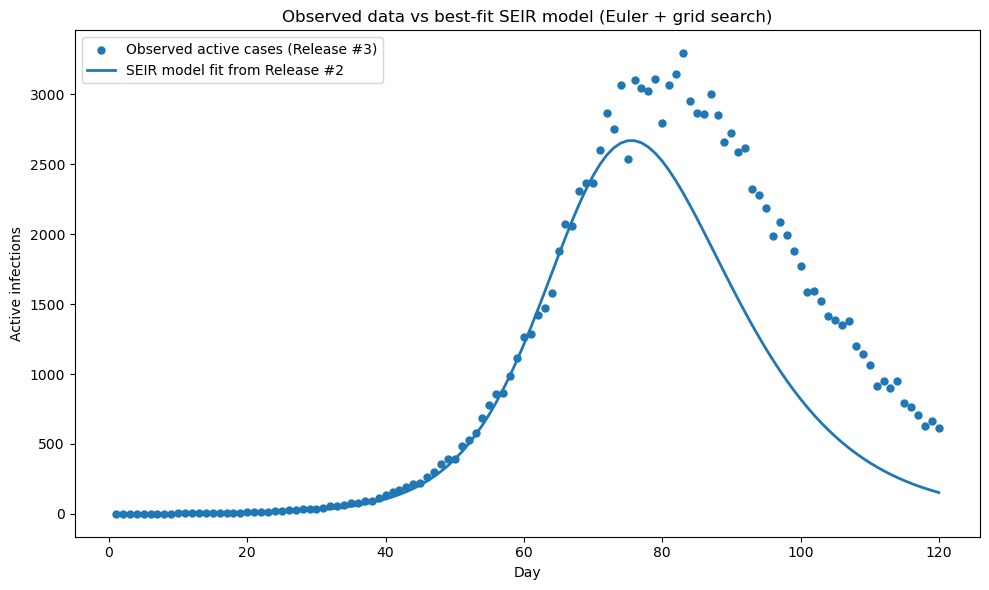

In [7]:
step("Day 4 - Part 2g")
main.exploratory_analysis_day4_2g()

Using the best-fit SEIR parameters from Data Release #2, we ran the model forward and compared it to the full observed Data Release #3 dataset. This served as a validation step, since the model was not re-fit to the new data. For this validation step, we also used a narrower second-pass grid search around the Release #2 best-fit region to see whether a slightly finer parameter search improved out-of-sample forecasting accuracy without changing the overall SEIR + Euler methodology. The observed epidemic peak in Data Release #3 occurred at day **83** with **3294.0** active infections, while the model predicted a peak at day **76** with **2669.6** active infections.

Using error definitions,

$$
E_t = \text{true value} - \text{approximation},
$$

the error in peak active infections was

$$
E_t = 3294.0 - 2669.6 = 624.4,
$$

with percent relative error

$$
\%e_t = \frac{624.4}{3294.0}\times 100\% \approx 18.96\%.
$$

For peak day, the error was

$$
E_t = 83 - 76 = 7 \text{ days},
$$

with percent relative error

$$
\%e_t = \frac{7}{83}\times 100\% \approx 8.43\%.
$$

Overall, the model captured the general epidemic timing and shape reasonably well, but it still **underestimated the true peak size** and predicted the peak **slightly too early**. Even so, the refined grid search improved the validation error enough to bring the peak-size percent error below 20%, which supports the idea that the fitted SEIR model gives a reasonably calibrated forecast while still leaving some model mismatch relative to the full outbreak.

### 2h. Intervention strategies for new outbreak at VT (70 days of infection)



### **Day 4 - Part 2h**


VT intervention comparison: peak metrics
Baseline: peak day 85, peak I 9784.6
Mask:     peak day 85, peak I 7980.3
Vax once: peak day 84, peak I 9211.9
Vax roll: peak day 84, peak I 9428.0
Combo:    peak day 83, peak I 7747.9

Sum of active infections over days 70–120 (burden proxy)
Baseline: 303743.1
Mask:     283287.8  (reduction 20455.2)
Vax once: 287292.3 (reduction 16450.8)
Vax roll: 282716.0 (reduction 21027.0)
Combo:    264615.1 (reduction 39127.9)


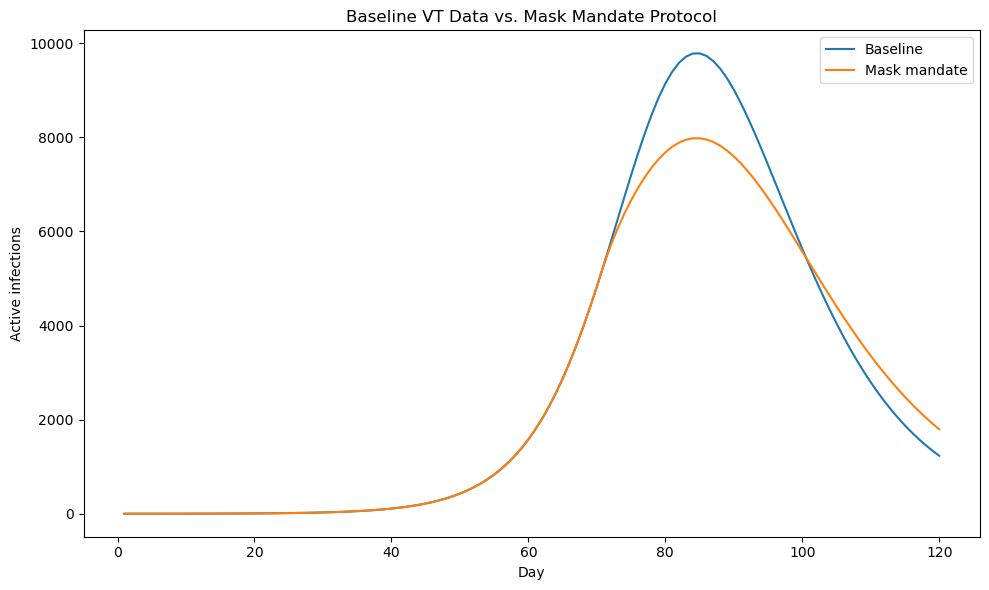

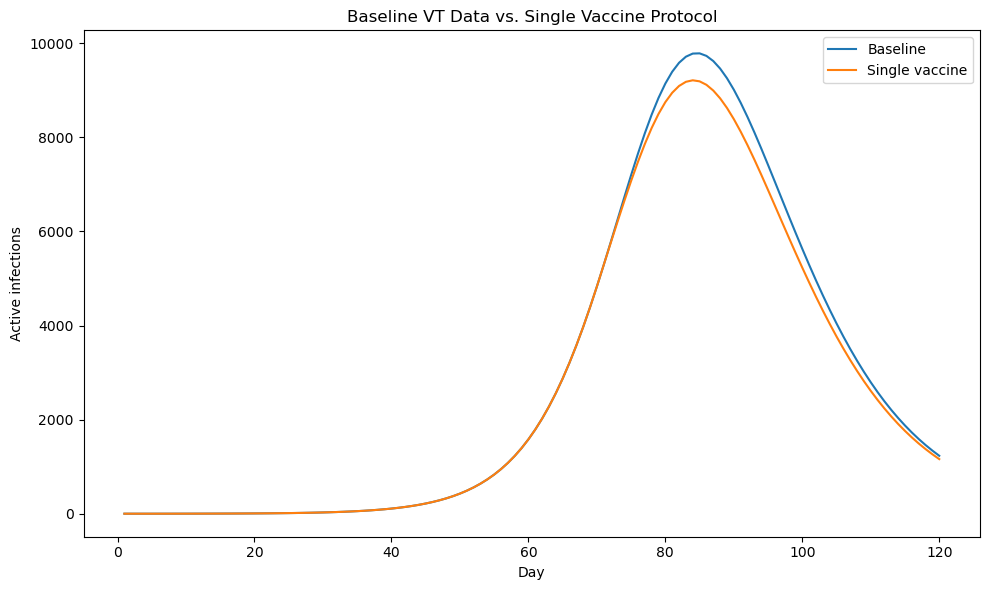

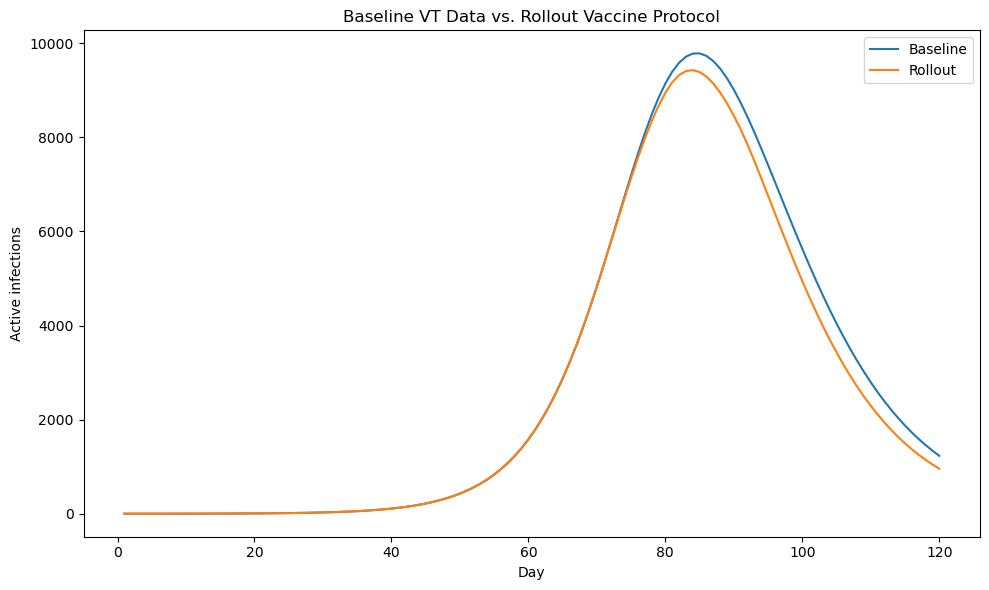

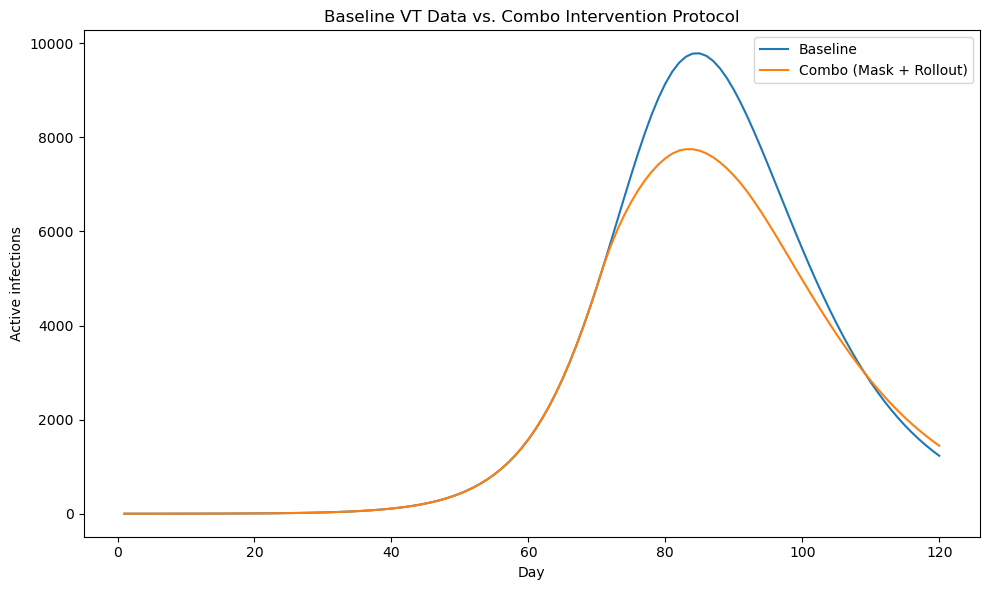

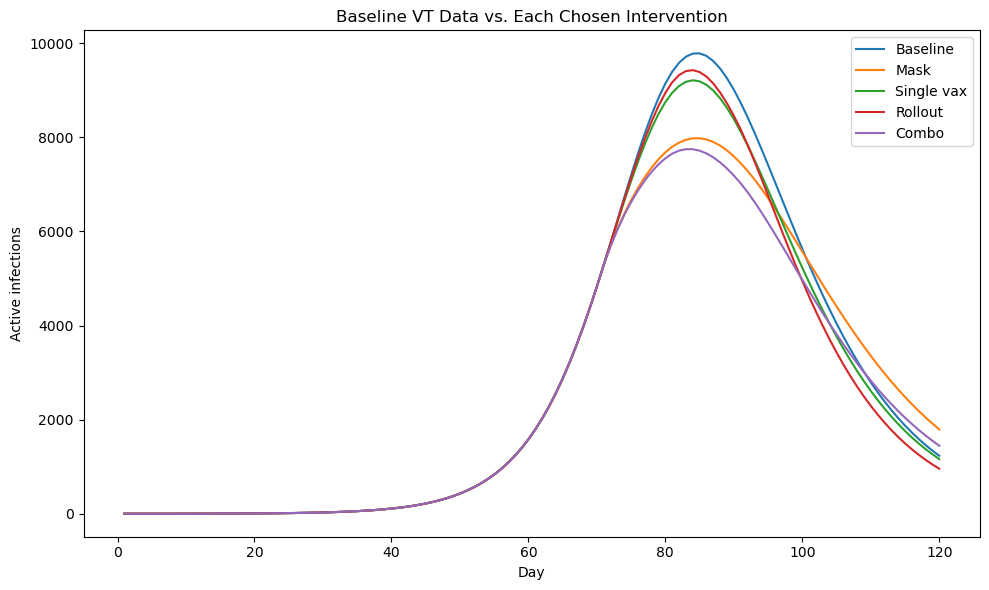

In [8]:
step("Day 4 - Part 2h")
main.exploratory_analysis_day4_2h()

Here, we used the best-fit SEIR parameters from Data Release #2 to model a new outbreak at VT and compared a baseline no-intervention case to four intervention scenarios beginning at day 70: masking, a one-time vaccine campaign, a staged vaccine rollout, and a combined masking + vaccine rollout strategy. The baseline scenario produced a peak of **9784.6** active infections at day **85**. This baseline result suggests a substantial outbreak in the larger VT population, with a later and much higher peak than in the mystery-virus fit for UVA. That is consistent with us scaling the outbreak to a larger susceptible population while keeping our same fitted transmission dynamics.

The masking intervention reduced the peak to **7980.3** active infections at day **85**, corresponding to a reduction of

$$
9784.6 - 7980.3 = 1804.3
$$

active infections at peak. The one-time vaccine campaign reduced the peak to **9211.9** at day **84**, a reduction of

$$
9784.6 - 9211.9 = 572.7.
$$

The vaccine rollout reduced the peak to **9428.0** at day **84**, a reduction of

$$
9784.6 - 9428.0 = 356.6.
$$

The combined masking + vaccine rollout intervention reduced the peak to **7747.9** at day **83**, a reduction of

$$
9784.6 - 7747.9 = 2036.7.
$$

We also compared the summed active infections over days 70–120 as a simple measure of total epidemic burden during the intervention period. The baseline burden was **303743.1**, while masking reduced this to **283287.8**, a reduction of **20455.2**. This is consistent with SEIR dynamics because a larger susceptible population allows sustained transmission for longer before depletion of susceptibles begins to slow the outbreak. The one-time vaccine campaign reduced the burden to **287292.3**, a reduction of **16450.8**. The vaccine rollout reduced the burden to **282716.0**, a reduction of **21027.0**. The combined intervention reduced the burden to **264615.1**, a reduction of **39127.9**.

These results suggest that the **combined masking + vaccine rollout strategy** was the most effective overall, because it produced both the **lowest epidemic peak** and the **largest reduction in total burden over days 70–120**. Among the single interventions, masking remained the most effective for reducing peak infections, while the staged vaccine rollout performed slightly better than masking for reducing cumulative burden.

### Extra Numerical Check: Step Size Sensitivity

### **Day 4 - Numerical Step Size Check**

Best-fit parameters from Release #2:
  beta  = 0.586
  sigma = 0.114
  gamma = 0.107
  SSE   = 98824.33

Euler step-size sensitivity check (forward prediction to day 300):
  h = 1.0  -> peak day = 75.00, peak active infections = 2556.40
  h = 0.5  -> peak day = 73.00, peak active infections = 2510.25
  h = 0.25 -> peak day = 72.00, peak active infections = 2487.85

Differences relative to h = 1.0:
  h = 0.5  -> day difference = -2.00, peak-I difference = -46.15
  h = 0.25 -> day difference = -3.00, peak-I difference = -68.55


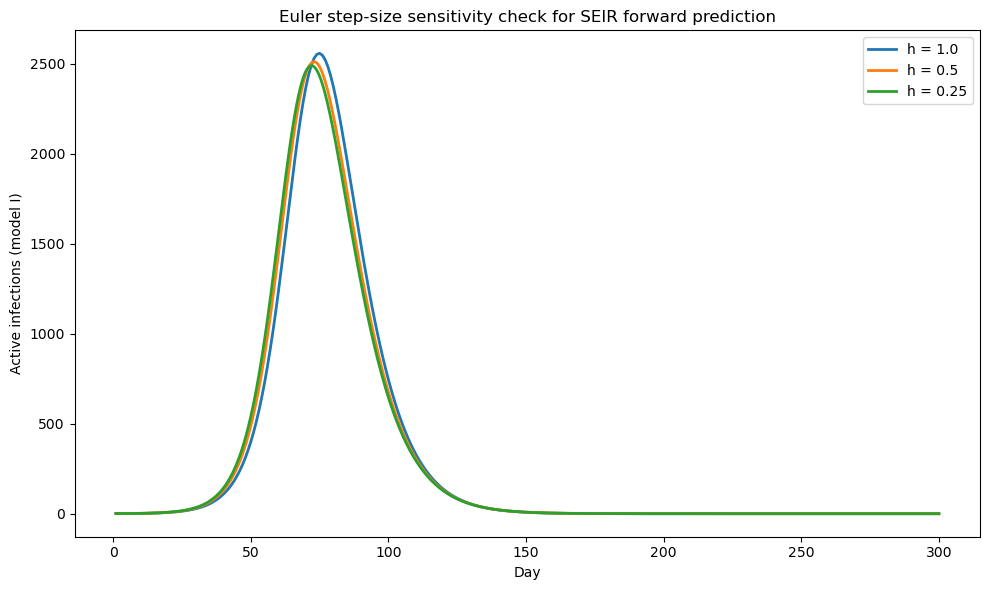

In [9]:
step("Day 4 - Numerical Step Size Check")
main.exploratory_analysis_day4_extra_stepcheck()

We also performed an extra numerical check to see whether our Euler forward prediction was sensitive to the step size $h$. Using the best-fit Release #2 parameters, we reran the forward SEIR prediction with $h=1.0$, $h=0.5$, and $h=0.25$.

The predicted peak changed from day **75** with **2556.4** active infections at $h=1.0$ to day **73** with **2510.3** active infections at $h=0.5$ and day **72** with **2487.9** active infections at $h=0.25$. Relative to the original $h=1.0$ run, this corresponds to changes of only **2–3 days** in peak timing and about **46–69 infections** in peak size.

Overall, this suggests that our main qualitative conclusion is numerically stable: i.e., reducing the Euler step size changes the prediction somewhat, but it does not completely change the epidemic trajectory or the existence of a peak in the low-to-mid 70s. This supports the idea that the model behavior is reasonably robust to the step size choice, even though Euler’s method still introduces truncation error which we noted.


## Verify and validate your analysis: 

### Verification:

We verified our code by checking that the Euler SEIR solver produced the expected compartment behavior: $S(t)$ decreased over time, while $E(t)$, $I(t)$, and $R(t)$ changed in biologically reasonable ways.

We also verified that our parameter fitting improved the model by using grid search to minimize

$$
\mathrm{SSE}=\sum\left(I_{\mathrm{obs}}-I_{\mathrm{model}}\right)^2.
$$

Our modeling process also matched the data available at each stage: Data Release #1 was used for an early exponential-growth estimate of $R_0$, Data Release #2 was used to fit the full SEIR model, and Data Release #3 was used to test that fitted model against new data and to run intervention scenarios.

As an additional numerical verification step, we repeated the forward SEIR prediction with smaller Euler step sizes ($h=0.5$ and $h=0.25$) and found that the predicted peak changed only modestly, which suggests the forward prediction is reasonably stable to the choice of step size.

Together, the good visual fit on Release #2 and the modest sensitivity to step size suggest that the numerical implementation is both internally consistent and reasonably stable.

We also verified that the combined masking + vaccine rollout scenario produced a stronger reduction than either single intervention alone, which is directionally consistent with the idea that layered interventions should outperform isolated ones in an SEIR framework.

### Validation:

We validated the model by comparing the Release #2 SEIR fit to the full Release #3 dataset. Using the refined validation script from Section 2g, the true peak was day **83** with **3294.0** active infections, while the model predicted day **76** with **2669.6** active infections.

Using

$$
E_t = \text{true value} - \text{approximation},
$$

the peak-size error was **624.4** infections, with

$$
\%e_t \approx 18.96\%.
$$

The peak-day error was **7 days**, with

$$
\%e_t \approx 8.43\%.
$$

These results suggest that the model captured the general outbreak trend reasonably well, but it still underestimated the true peak and predicted it slightly too early.

A useful consistency check was comparing our early-growth estimate of $R_0$ from Data Release #1 to the mechanistic SEIR-based estimate from the original Release #2 fit. The exponential-fit approach gave an approximate $R_0 \approx 2.937$, while the fitted SEIR model from Section 2d gave

$$
R_0=\frac{\beta}{\gamma}\approx \frac{0.586}{0.107}\approx 5.467.
$$

These values are not identical, which is reasonable because the early estimate used incomplete data and an assumed infectious-period range, while the later estimate used more data and a compartmental model. This comparison helped reinforce that early outbreak estimates are provisional and should be updated as additional data become available.

In addition, the refined second-pass validation search in Section 2g produced a nearby fitted value of

$$
R_0=\frac{\beta}{\gamma}\approx \frac{0.548}{0.102}\approx 5.367,
$$

showing that small changes in parameter search resolution can modestly improve forecast accuracy while leaving the overall epidemiological interpretation similar.

### Potential Sources of Error and Limitations of Our Approach:

Our early $R_0$ estimate from exponential growth (**2.937**) was based on incomplete data, so it was more uncertain than the later SEIR-based estimate from our main Release #2 fit,
$$
R_0=\frac{\beta}{\gamma}\approx \frac{0.586}{0.107}\approx 5.467.
$$

A refined second-pass grid search used later for validation in Section 2g gave a nearby value of about **5.367**, showing that fitted parameter values can shift somewhat depending on search resolution even when the overall outbreak interpretation remains similar.

The model also assumes homogeneous mixing, fixed parameters before intervention, and a fixed population size, which likely oversimplify real outbreak behavior.

Because Euler’s method is a numerical approximation, some error may also come from step size and truncation error, in addition to model error and noisy data.




## Conclusions and Ethical Implications: 

### Analysis Conclusions:

Our results suggest that the mystery virus is fairly transmissible. The early exponential estimate gave $R_0 \approx 2.937$, while the main best-fit SEIR model from Data Release #2 gave

$$
R_0 \approx 5.467.
$$

Although these are not identical, both indicate meaningful spread in a university population.

The best-fit SEIR parameters gave a latent period of about

$$
\frac{1}{\sigma}\approx \frac{1}{0.114}\approx 8.8 \text{ days}
$$

and an infectious period of about

$$
\frac{1}{\gamma}\approx \frac{1}{0.107}\approx 9.3 \text{ days},
$$

which are plausible as effective population-level model parameters, even though they do not match the exact within-host biological timing reported for RSV in the literature. Using `viruses.html` as a rough transmissibility screen and then comparing candidate viruses to published symptom and timing information, we conclude that the mystery virus is most consistent with **RSV or an RSV-like respiratory virus in the Pneumoviridae family** ($R_0 = 6$) [1]–[4]. RSV is a stronger overall match than chart-neighbors such as norovirus ($R_0 = 5$) because RSV is a respiratory virus with cough, congestion, sneezing, fever, and wheezing, and CDC notes that infected people may spread RSV a day or two before symptoms begin [1], [2]. We therefore used the chart only for rough comparison and relied on literature and biological context for the final identification. For that reason, we interpret RSV as the closest overall qualitative match rather than claiming that our fitted SEIR parameters recover the exact biological constants of RSV.

A refined second-pass parameter search used in our validation step produced a nearby estimate of $R_0 \approx 5.367$, which slightly improved the out-of-sample peak prediction but did not change our overall conclusion that the mystery virus is consistent with a highly transmissible RSV-like respiratory virus.

For the VT intervention analysis, all four intervention scenarios improved outcomes compared with baseline. Among the single interventions, masking produced the largest reduction in the epidemic peak:

$$
9784.6 - 7980.3 = 1804.3,
$$

while the staged vaccine rollout produced the largest reduction in total burden over days 70–120 among the single interventions:

$$
303743.1 - 282716.0 = 21027.0.
$$

Based on these results, we would recommend the **combined masking + vaccine rollout strategy** as the strongest overall intervention because it produced both the lowest peak (**7747.9**) and the largest cumulative burden reduction (**39127.9**) relative to baseline. If the decision-makers in charge are restricted to a single intervention, the **masking mandate** is the strongest single option for reducing the maximum number of simultaneous infections, while the staged vaccine rollout also performs well for reducing total burden over time.

Our recommendation depends not only on the decision objective, but also on whether campus leaders can realistically implement one intervention or combine multiple interventions. In our results, the combined masking + vaccine rollout strategy performed best overall because it reduced both peak infections and cumulative burden more than any single intervention alone. Among single interventions, masking was strongest for reducing the maximum number of simultaneous infections, while the staged vaccine rollout slightly outperformed masking for reducing total burden over the intervention window. In model terms, masking works by directly lowering the transmission parameter $\beta$, while vaccination reduces the susceptible pool by moving individuals from $S$ to $R$. This shows that the “best” intervention is not purely biological or mathematical but it is also depends on implementation feasibility, logistics, participation, and whether layered interventions are possible in practice.

### Ethical Implications:

These model results should not be treated as exact forecasts. Our validation results showed that the model underestimated the true peak and predicted it too early, so any policy recommendation should be communicated with uncertainty.

Interventions also have unequal burdens. Masking is relatively low-cost, but compliance may vary and some groups may face more difficulty with prolonged masking. Vaccine-based strategies may reduce burden, but they depend on equitable access, trust, and participation.

Our model assumes that all individuals mix similarly and have similar risk, which is not true in real campus populations. Because of that, recommendations should be used as general guidance rather than as perfectly precise policy instructions for every subgroup.

These results also highlight that model-based recommendations can affect groups differently. Students in dormitories, students with disabilities, students with limited access to healthcare, and students working high-contact jobs may not experience the same risks or the same ability to comply with interventions. Because of this precise reason, ethical outbreak policy should be a robust combination of quantitative modeling with attention to equity, access, and who bears the burden when model assumptions fail.

The combined intervention was most effective in the model, but it may also place greater demands on the population because it requires both behavioral compliance with masking and access to repeated vaccination efforts. Ethically, a more effective intervention is not automatically the fairest or easiest to implement, so public-health recommendations should balance epidemiological benefit with feasibility and equity.

## Limitations and Future Work: 

One major limitation of using SEIR models with real viral datasets is the oversimplification of disease dynamics. SEIR models assume fixed latent and infectious periods, no asymptomatic transmission, and no age‑ or contact‑based structure. Real respiratory viruses rarely behave this uniformly, so these assumptions can lead to inaccurate representations of how infections actually spread. Another important limitation involves data quality. Because our dataset only included active reported cases, it could not account for underreporting, delays in testing, or changes in surveillance practices over time. If the underlying data are incomplete or biased, the model’s output will not accurately reflect the true course of the disease.

For future work, the goal should be to reduce model inaccuracies and move toward a more realistic representation of viral transmission. This could involve using age-structured or network-based SEIR models, which better capture how different groups interact and experience infection differently. Parameter estimation could also be strengthened by replacing simple grid search with approaches like particle filtering [6] or maximum likelihood estimation [7], both of which provide uncertainty intervals and more reliable fits. Finally, incorporating additional data streams, such as hospitalizations, seroprevalence, or wastewater signals, would help correct for biases in reported case counts and allow the model to reflect the true underlying epidemic more accurately.



## **Notes:** 

* **Completed:**
    * Data and Disease Background: Reagan

    * Data Analysis: Will and Reagan

    * Verification/Validation: Will
    
    * Conclusions/Ethics: Will

    * Limitations/Future Work: Reagan


* **To Do:**
    * Nothing at this time.


* **Questions/Concerns:**
    * Nothing at this time.


* **References:**
    * [1] CDC. “Symptoms and Care of RSV.” Updated 2026.
    * [2] CDC. “How RSV Spreads.” Updated 2026.
    * [3] CDC. “Clinical Overview of RSV.” Updated 2025.
    * [4] WHO. “Respiratory syncytial virus (RSV).” Updated 2025.
    * [5] CDC Yellow Book. “Norovirus.” Updated 2025.
    * [6] Wills, A. G., & Schön, T. B. (2023). 
    * [7] Ríos-Gutiérrez, A., Torres, S., & Arunachalam, V. (2023).
    * [8] Course Lecture 1: Modeling the Spread of Viruses
    * [9] Course Lecture 2: Epidemics & the SIR Model
    * [10] Course Lecture 3: Euler’s Method
    * [11] Course Lecture 4: Predicting the Effect of Interventions
    * [12] Course Lecture 5: More Accurate Numerical Solvers for ODEs
    * [13] `viruses.html` visualization file
    * [14] `seir_grid_search.html` class material




* **AI Statement:**
    * External use of LLMs was utilized on a case-by-case basis, often for initial source discovery + inspiration and code debugging. GitHub Copilot (which we students have a free trial) was especially helpful with providing 'Inline Suggestions' for shortening time with boilerplate code and repetitive function naming. This was particularly helpful for implementing LaTeX format into our markdown segments to that we can easily see the equations being used in a clear sense. However, the final code structure, modeling choices, and interpretations were based on the course lectures, GitHub materials, and provided resources, with all final analysis completed by our team. 





## **TA Questions:** 
*We have no questions at this time.*